# PCA 

Doing principal component analysis on gene expression (bulk RNA-seq) data on HGSOC samples. We're particularly interested if the samples cluster nicely by sample location (ovary, omentum, etc) after PCA.

We have bulk tissue, rRNA-, bulk sequenced and dissociated bulk tissue, poly A+, bulk sequenced this notebook can be executed for either type data. To switch data types, change the count matrix .csv file that is loaded.


The PC plot does not show a nice clustering by sample location, and it seems that the principal components are mostly driven by a few outliers.

In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

In [12]:
from support_dea import gene_ensemble_id_mapping

## Load data

In [13]:
DATA_PATH = f"{os.getcwd()}/../data/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [14]:
# Load the GTF file and create a mapping of gene names to Ensembl IDs
gtf = gene_ensemble_id_mapping(GTF_PATH)
dict(gtf[:5])

{'ENSG00000204435': 'CSNK2B',
 'ENSG00000106013': 'ANKRD7',
 'ENSG00000129038': 'LOXL1',
 'ENSG00000103852': 'TTC23',
 'ENSG00000225963': 'ENSG00000225963'}

In [30]:
# Load the count matrix
count_df = pd.read_csv(DATA_PATH + "count_matrix_Dissociated Bulk_site.csv", index_col=0)

In [41]:
count_df.head()

,Site of origin,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000291296,ENSG00000291297,ENSG00000291299,ENSG00000291300,ENSG00000291309,ENSG00000291317,ENSG00000291342,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,Omentum,485,1,1400,86,78,845,2036,843,376,...,3,5,426,15,9,47,4,0,1,2
230414/2460,Omentum,499,3,836,88,77,417,3003,548,338,...,4,2,177,117,5,204,1,0,0,0
230414/2416,Ovary,466,11,402,122,79,465,384,359,188,...,10,6,151,7,0,38,0,0,6,12
230414/2278,Omentum,557,3,3726,340,209,712,2999,912,480,...,7,2,833,158,43,678,8,1,1,0
230414/2249,Ovary,430,4,1119,311,216,541,3651,1355,308,...,3,0,334,18,5,97,1,0,0,0


In [32]:
# Sample locations tally
count_df["Site of origin"].value_counts()

Site of origin
Omentum    10
Ovary       5
Name: count, dtype: int64

## Normalize data

In [33]:
# Calculate the median expression for each gene across all samples for normalization
medians = np.median(count_df.drop(columns=["Site of origin"]), axis=1)

In [ ]:
# Check for strangely behaved genes
count_df[medians==0].index

Index([], dtype='object', name='Long Sample ID')


In [43]:
metadata_df = count_df["Site of origin"]
count_df = count_df.drop(columns=["Site of origin"])

In [48]:
# Normalization of the count matrix
# Every row / sample is getting normalized by the median number of counts of that row / sample
M = np.vstack([np.median(count_df, axis=1)] * len(count_df.columns)).T
norm_count_df = pd.DataFrame(count_df / M)

In [49]:
norm_count_df.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000291296,ENSG00000291297,ENSG00000291299,ENSG00000291300,ENSG00000291309,ENSG00000291317,ENSG00000291342,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,12.125000,0.025000,35.000000,2.150000,1.950000,21.125000,50.900000,21.075000,9.400000,14.400000,...,0.075000,0.125000,10.650000,0.375000,0.225000,1.175000,0.100000,0.000000,0.025000,0.050000
230414/2460,14.257143,0.085714,23.885714,2.514286,2.200000,11.914286,85.800000,15.657143,9.657143,11.628571,...,0.114286,0.057143,5.057143,3.342857,0.142857,5.828571,0.028571,0.000000,0.000000,0.000000
230414/2416,13.314286,0.314286,11.485714,3.485714,2.257143,13.285714,10.971429,10.257143,5.371429,9.142857,...,0.285714,0.171429,4.314286,0.200000,0.000000,1.085714,0.000000,0.000000,0.171429,0.342857
230414/2278,6.476744,0.034884,43.325581,3.953488,2.430233,8.279070,34.872093,10.604651,5.581395,10.662791,...,0.081395,0.023256,9.686047,1.837209,0.500000,7.883721,0.093023,0.011628,0.011628,0.000000
230414/2249,10.000000,0.093023,26.023256,7.232558,5.023256,12.581395,84.906977,31.511628,7.162791,13.534884,...,0.069767,0.000000,7.767442,0.418605,0.116279,2.255814,0.023256,0.000000,0.000000,0.000000


## PCA

In [50]:
pca = PCA(n_components=2)
components = pca.fit_transform(norm_count_df.sort_index())

In [51]:
pca.explained_variance_ratio_

array([0.52849691, 0.20237093])

## Visualization

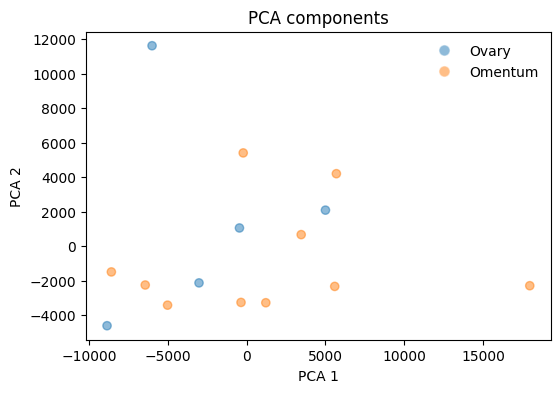

In [ ]:
color = ["C0" if x=="Ovary" else "C1" for x in metadata_df]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.scatter(components[:, 0], components[:, 1], c=color, alpha=0.5)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(
    handles=[
        Line2D([0], [0], color="w", marker='o', markerfacecolor="C0", markersize=8, alpha=0.5),
        Line2D([0], [0], color="w", marker='o', markerfacecolor="C1", markersize=8, alpha=0.5),
    ],
    labels=["Ovary", "Omentum"],
    frameon=False,
    loc='upper right'
)
ax.set_title("PCA components")
# I suspect that the explained variance of PCA 1 being very highly is at least partially due to the outlier sample

plt.show()

In [ ]:
figname = f"{os.getcwd()}/../results/figures/PCA_plot_diss_bulk_site_of_origin"
fig.savefig(figname + ".png", bbox_inches="tight")
fig.savefig(figname + ".pdf", bbox_inches="tight")